## Evaluation and minimization of the loss function

In [1]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from pH_refine import load_pH_data, pH_loss, pH_tilde_loss_and_grad, Lambdas

### 1. load data

load data from experiments and MD simulations

- load data after WHAM has been performed as described in `WHAM.ipynb`

`WHAM.ipynb` performs WHAM and returns:
- `WHAM_df.txt` (weights as output of WHAM, protonation numbers and observables from concatenated trajectories from multiple constant pH MD simulations)
- `WHAM_pops_3.98.txt` (populations of the protonation states indicated in columns at a reference pH chosen as the closest one to the pKa, namely, to 50/50 populations -- notice this value of the pH is not present in the original MD simulations, but it is very close to one of them)

In [3]:
from pH_refine import PHData, compute_pH_weights

##### input data
- weights, protonation numbers, observables (from `WHAM_df.txt`)
- populations at reference pH (from `WHAM_pops_3.98.txt`)
- values of pH `pH_vals`

In [4]:
my_df = pandas.read_csv('Simulation-data/A3mer/WHAM_df.txt', index_col=0)

my_df

,weight,n_prot,chi,eRMSD
0,7.853643e-06,1.0,-1.050246,1.054092
1,1.578589e-05,1.0,-1.043169,1.175289
2,2.126278e-07,1.0,-0.292339,1.103215
3,1.271614e-07,1.0,-0.155172,1.130084
4,5.902291e-08,1.0,-0.016830,1.108039
...,...,...,...,...
112495,1.273789e-05,1.0,-0.931121,1.180245
112496,6.969360e-07,1.0,-0.388632,1.166304
112497,5.355708e-06,1.0,-0.803565,1.224548
112498,2.534988e-06,1.0,-0.592147,1.194844


In [5]:
ref_pops = np.array(pandas.read_csv('Simulation-data/A3mer/WHAM_pops_3.98.txt', index_col=0))[0]
ref_pH = 3.98

ref_pops

array([0.51023236, 0.48976764])

In [6]:
pH_vals = [3.0, 3.5, 4.0]

##### load data
from the two files indicated above, you get:
- set of possible protonation numbers/states `ns_prot`
- observables split for each protonation state `gs`
- pH differences `delta_pH_vals` (and corresponding `log_fugacities`)
- average values (and associated errors) at fixed protonation state and at fixed pH (the latter are weighted averages of the first ones); they can be used to get synthetic experimental data
- populations of the two protonation states at reference pH (required to evaluate and minimize the loss) and at pH values in `pH_vals`
- canonical (normalized) weights for each protonation state

In [7]:
ns_prot = np.unique(my_df['n_prot']).astype(int)

ns_prot

array([0, 1])

In [8]:
my_obs = my_df[['chi', 'eRMSD']]

gs = {}

for n_prot in ns_prot:
    gs[n_prot] = np.array(my_obs[my_df['n_prot'] == n_prot])

In [9]:
delta_pH_vals = np.array(pH_vals) - ref_pH

log_fugacities = -np.array(delta_pH_vals)*np.log(10)

In [10]:
avs_prot = {}

for j in range(2):
    avs_prot[j] = np.dot(my_obs[my_df['n_prot'] == j].T, my_df['weight'][my_df['n_prot'] == j])/np.sum(my_df['weight'][my_df['n_prot'] == j])

avs_prot

{0: array([-0.51081261,  1.06871165]), 1: array([0.54940919, 1.22269712])}

In [11]:
avs = {}
stds = {}
kish = {}
errs = {}

for pH in pH_vals:
    logf = -pH*np.log(10)
    w = compute_pH_weights(np.log(np.array(my_df['weight'])), logf, np.array(my_df['n_prot']))
    avs[logf] = np.dot(my_obs.T, w)
    stds[logf] = np.sqrt(np.dot((my_obs**2).T, w) - avs[logf]**2)
    kish[logf] = np.sum(w**2)
    errs[logf] = stds[logf]*np.sqrt(kish[logf])

In [12]:
print('averages:\n', pandas.DataFrame(avs))
print('\nerrors on averages:\n', pandas.DataFrame(errs))
print('\nstds:\n', pandas.DataFrame(stds))

averages:
    -6.907755  -8.059048  -9.210340
0   0.445127   0.277476  -0.003744
1   1.207551   1.183202   1.142358

errors on averages:
    -6.907755  -8.059048  -9.210340
0   0.015258   0.014024   0.013469
1   0.001854   0.001833   0.001902

stds:
    -6.907755  -8.059048  -9.210340
0   1.575605   1.670041   1.782398
1   0.191443   0.218231   0.251736


- compare with populations of the two protonation states: the average values at a given pH are in between the two extreme cases of the averages at one or the other protonation state
- in principle, `pops` can also be the populations of the different protonation states from multiple constant-pH MD simulations (this attribute of the `PHData` class is used by `compute_pH_consistency` but not to evaluate and minimize the loss function)

In [13]:
pops = {}

for pH in pH_vals:
    logf = -(pH - ref_pH)*np.log(10)
    pops[pH] = compute_pH_weights(np.log(ref_pops), logf, np.array([0, 1]))

pops

{3.0: Array([0.09835848, 0.90164152], dtype=float64),
 3.5: Array([0.2564875, 0.7435125], dtype=float64),
 4.0: Array([0.52173302, 0.47826698], dtype=float64)}

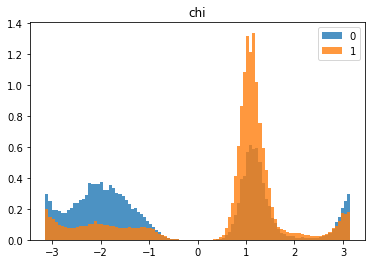

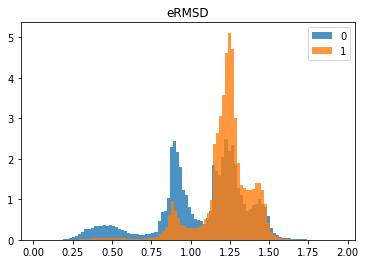

In [14]:
obs_names = ['chi', 'eRMSD']

for name in obs_names:
    plt.figure()
    plt.title(name)

    for i in range(2):
        plt.hist(my_df[name][my_df['n_prot'] == i], weights=my_df['weight'][my_df['n_prot'] == i],
                alpha=0.8, bins=100, label=i, density=True)

    plt.legend()

In [15]:
weights = {}

for n_prot in ns_prot:
    weights[n_prot] = np.array(my_df['weight'][my_df['n_prot'] == n_prot])
    weights[n_prot] /= np.sum(weights[n_prot])

weights

{0: array([4.42346099e-07, 1.18166257e-05, 1.02347386e-07, ...,
        4.79335366e-05, 2.67926326e-05, 1.36390210e-05]),
 1: array([7.85449964e-06, 1.57876092e-05, 2.12651042e-07, ...,
        6.97012053e-07, 5.35629209e-06, 2.53526442e-06])}

In [16]:
from pH_refine import ManageIndices

In [17]:
g_exp = ManageIndices.flatten(np.array(pandas.DataFrame(avs)))
sigma_exp = ManageIndices.flatten(np.array(pandas.DataFrame(errs)))

legend_matrix = ManageIndices.build_legend(np.array(pandas.DataFrame(avs)))[0]


In [18]:
data = PHData(g_exp, sigma_exp, legend_matrix, gs, weights, None, ref_pH, ref_pops, pops, log_fugacities, ns_prot, obs_names, pH_vals)

In [19]:
data.keys()

dict_keys(['g_exp', 'sigma_exp', 'legend_matrix', 'gs', 'p0s', 'legend_weights', 'ref_pH', 'ref_pops', 'pops', 'log_fugacities', 'ns_prot', 'obs_names', 'pH_vals'])

In [20]:
data.pops

{3.0: Array([0.09835848, 0.90164152], dtype=float64),
 3.5: Array([0.2564875, 0.7435125], dtype=float64),
 4.0: Array([0.52173302, 0.47826698], dtype=float64)}

### 2nd step: evaluate the loss function for the original `data`

In [21]:
pi_vec = data.ref_pops
lambdas_vec = np.zeros(len(data.g_exp))

out = pH_loss(lambdas=lambdas_vec, pis=pi_vec, data=data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

### 3rd step: minimize the loss function through `pH_tilde_loss`
(dimensionality reduction with `lambdas`)

In [22]:
log_pi_vec = np.log(pi_vec)


In [23]:
# is_fixed = False, so inner minimization of Gamma (required to compute the gradient)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

pH_tilde_loss_and_grad(log_pi_vec, data, lambdas)


loss, grad:  -1.1329434389867456e-16 [0. 0.]
pi_vec:  [0.51023236 0.48976764]




(Array(-1.13294344e-16, dtype=float64), Array([0., 0.], dtype=float64))

In [24]:
args = (data, lambdas)

mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)


loss, grad:  -1.1329434389867456e-16 [0. 0.]
pi_vec:  [0.51023236 0.48976764]




In [25]:
mini

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.1329434389867456e-16
        x: [-6.729e-01 -7.138e-01]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 1
     njev: 1

In [26]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.51023236, 0.48976764])

In [27]:
vars(lambdas)

{'value': array([0., 0., 0., 0., 0., 0.]), 'is_fixed': False}

### 4. evaluate `pH_loss` on the optimal solution
- do the values of the loss function agree?
- is this value lower than the starting one?

In [28]:
out = pH_loss(lambdas.value, pi_new, data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

In [29]:
print(mini.fun, out.loss)

-1.1329434389867456e-16 7.693513204315125e-24


yes, they agree!

In [30]:
out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

### 5. modify synthetic "experimental" data
such that they do not match the original average values

In [31]:
print(g_exp)
print(data.sigma_exp*10)

[ 0.44512738  0.27747556 -0.00374353  1.20755134  1.18320177  1.14235782]
[0.15257762 0.14023983 0.13469085 0.01853883 0.01832573 0.01902298]


In [32]:
rescaling = 10
random_fact = np.random.normal(size=len(data.g_exp))
print(random_fact)

data.g_exp = g_exp + random_fact*data.sigma_exp*rescaling

data.g_exp

[-0.09757695 -0.09962696  1.0318245  -0.15182002  0.26383468  0.05789095]


Array([0.43023932, 0.26350389, 0.13523379, 1.20473678, 1.18803674,
       1.14345908], dtype=float64)

In [33]:
lambdas = np.zeros(len(data.g_exp))
pH_loss(lambdas, pi_vec, data)

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(59.00590088, dtype=float64)
        chi2: Array(118.01180175, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(59.00590088, dtype=float64)
    rel_diff: Array([[  0.97576947,   0.99626957, -10.31824504],
                     [  1.51820022,  -2.63834679,  -0.57890951]], dtype=float64)

In [34]:
log_pi_vec = np.log(pi_vec)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

pH_tilde_loss_and_grad(log_pi_vec, data, lambdas)

loss, grad:  8.794427052007071 [ 2.30390789 -2.30390789]
pi_vec:  [0.51023236 0.48976764]




(Array(8.79442705, dtype=float64),
 Array([ 2.30390789, -2.30390789], dtype=float64))

In [35]:
args = (data, lambdas)

mini = minimize(pH_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)

loss, grad:  8.794427052007071 [ 2.30390789 -2.30390789]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  11.104612409154297 [-2.99636792  2.99636792]
pi_vec:  [0.19981987 0.80018013]


loss, grad:  8.528567934303489 [-0.27425501  0.27425501]
pi_vec:  [0.4382792 0.5617208]


loss, grad:  8.523502478381008 [-0.05222778  0.05222778]
pi_vec:  [0.44586376 0.55413624]


loss, grad:  8.523311295483673 [ 0.00086584 -0.00086584]
pi_vec:  [0.44765169 0.55234831]


loss, grad:  8.52331119809171 [ 0.00081224 -0.00081224]
pi_vec:  [0.44762252 0.55237748]


loss, grad:  8.523310862130046 [ 0.00060314 -0.00060314]
pi_vec:  [0.44750585 0.55249415]


loss, grad:  8.523313794887033 [-0.00343033  0.00343033]
pi_vec:  [0.44717106 0.55282894]


loss, grad:  8.523311394142322 [-0.0007379  0.0007379]
pi_vec:  [0.44748127 0.55251873]


loss, grad:  8.523311324581288 [-0.00070767  0.00070767]
pi_vec:  [0.44750539 0.55249461]


loss, grad:  8.523311323140419 [-0.00091455  0.00091455]
pi_vec:  [0.44750585 0.5524

In [36]:
mini

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 8.523310862130046
        x: [-7.987e-01 -5.880e-01]
      nit: 4
      jac: [ 6.031e-04 -6.031e-04]
 hess_inv: [[ 1.061e+00 -6.131e-02]
            [-6.131e-02  1.061e+00]]
     nfev: 25
     njev: 13

In [37]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.44750585, 0.55249415])

In [38]:
pKa = data.ref_pH - np.log10(pi_new[0]/pi_new[1])

print('optimal pKa: ', pKa)

optimal pKa:  4.071528968935663


In [39]:
logf = -(pKa - ref_pH)*np.log(10)
compute_pH_weights(np.log(pi_new), logf, np.array([0, 1]))


Array([0.5, 0.5], dtype=float64)

In [40]:
out = pH_loss(lambdas.value, pi_new, data)

out

         avs: Array([[-0.27194749,  1.0563011 ],
                     [ 0.45702251,  1.21952311]], dtype=float64)
      avs_ph: Array([[0.40002904, 0.3028559 , 0.12248547],
                     [1.20676183, 1.18500402, 1.14461768]], dtype=float64)
 check_gamma: Array(2.10282433e-05, dtype=float64)
        chi2: Array(16.99296306, dtype=float64)
       dkl_p: Array([0.01708652, 0.00188479], dtype=float64)
      dkl_pi: Array(0.00787975, dtype=float64)
       gamma: Array(-8.51543181, dtype=float64)
      log_ps: [Array([-14.62236726, -11.148281  , -15.9968661 , ..., -10.09299923,
                     -10.61952109, -11.31020479], dtype=float64), Array([-11.69800755, -10.99339985, -15.33651946, ..., -14.14177205,
                     -12.08173968, -12.8403173 ], dtype=float64)]
        loss: Array(8.52333259, dtype=float64)
    rel_diff: Array([[-1.97999452,  2.80605074, -0.94648768],
                     [ 1.09233217, -1.65489699,  0.60905782]], dtype=float64)

In [41]:
print(out.loss, mini.fun)

if np.abs(out.loss - mini.fun) < 1e-3: print('yes, they agree!')
else: print('significant mismatch, possible errors!')

8.523332586858503 8.523310862130046
yes, they agree!


### 6. define `pH_minimizer` function

so, let's define a function that minimizes the loss through `pH_tilde_loss` and returns results of `pH_loss`

the function `pH_minimizer` has been developed here and included in `pH_refine.py`

In [ ]:
from pH_refine import pH_minimizer

In [43]:
result = pH_minimizer(data, alpha_pi=10.)

loss, grad:  8.79442705200707 [ 2.30390789 -2.30390789]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  12.95403984349454 [-5.05181039  5.05181039]
pi_vec:  [0.19981987 0.80018013]


loss, grad:  8.580495485296112 [-0.21870765  0.21870765]
pi_vec:  [0.45616707 0.54383293]


loss, grad:  8.5781865209122 [-0.0251055  0.0251055]
pi_vec:  [0.46083198 0.53916802]


loss, grad:  8.578138758600927 [-0.0137949  0.0137949]
pi_vec:  [0.46143742 0.53856258]


loss, grad:  8.57819666352881 [ 0.03101595 -0.03101595]
pi_vec:  [0.462176 0.537824]


loss, grad:  8.578132227055468 [ 0.01884391 -0.01884391]
pi_vec:  [0.46153813 0.53846187]


loss, grad:  8.578127917771944 [ 0.01798866 -0.01798866]
pi_vec:  [0.46147998 0.53852002]


loss, grad:  8.578153458612498 [-0.00040739  0.00040739]
pi_vec:  [0.46145189 0.53854811]


loss, grad:  8.578153432853417 [-9.03993773e-05  9.03993773e-05]
pi_vec:  [0.46147963 0.53852037]


loss, grad:  8.57815343262342 [-0.00027189  0.00027189]
pi_vec:  [0.46147998 0.53852

In [44]:
result

         avs: Array([[-0.25300812,  1.06079519],
                     [ 0.45952621,  1.21997301]], dtype=float64)
      avs_ph: Array([[0.40086263, 0.30204996, 0.12256859],
                     [1.20686776, 1.18479334, 1.14469779]], dtype=float64)
 check_gamma: Array(8.96587223e-06, dtype=float64)
        chi2: Array(17.0236227, dtype=float64)
        diff: 2.368892797299793e-05
       dkl_p: Array([0.01689251, 0.00180746], dtype=float64)
      dkl_pi: Array(0.00476511, dtype=float64)
       gamma: Array(-8.53050235, dtype=float64)
     lambdas: array([-126.18558757,  195.9756838 ,  -69.86311037,  621.31352893,
                     -964.5544312 ,  343.67350642])
      log_ps: [Array([-14.61677824, -11.14826753, -15.9995418 , ..., -10.09004338,
                     -10.61806786, -11.30423698], dtype=float64), Array([-11.70079595, -10.99458143, -15.33835831, ..., -14.14281396,
                     -12.08217466, -12.84106189], dtype=float64)]
        loss: Array(8.57816245, dtype=float64)

In [45]:
result.diff

2.368892797299793e-05

In [58]:
print(data.ref_pops, result.pi_new)

[0.51023236 0.48976764] [0.49374729 0.50625271]


try with different values of the hyperparameters and compare the optimal solutions:
- with a lower $\alpha_\pi$, the solution is further from the reference populations of the two protonation states (higher $D_{KL}$, further values of the populations)

In [59]:
result = pH_minimizer(data, alpha_pi=1e5)

loss, grad:  8.794427051995742 [ 2.30390789 -2.30390789]
pi_vec:  [0.51023236 0.48976764]


loss, grad:  20560.092835363583 [-22841.01756427  22841.01756427]
pi_vec:  [0.19981987 0.80018013]


loss, grad:  8.794322468705653 [ 0.28026427 -0.28026427]
pi_vec:  [0.51021214 0.48978786]


loss, grad:  8.794320897610914 [-8.49087631e-05  8.49087631e-05]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.79432089762556 [-1.10279307e-06  1.10279307e-06]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.794320897629863 [-8.46365216e-05  8.46365216e-05]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.794320897610914 [-8.49087631e-05  8.49087631e-05]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.794320897622299 [-8.49087556e-05  8.49087556e-05]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.794320897610914 [-8.49087631e-05  8.49087631e-05]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.794320897622299 [-8.49087556e-05  8.49087556e-05]
pi_vec:  [0.51020934 0.48979066]


loss, grad:  8.7

In [60]:
result

         avs: Array([[-0.19451754,  1.07476691],
                     [ 0.46923586,  1.22174482]], dtype=float64)
      avs_ph: Array([[0.40395551, 0.29900308, 0.12294906],
                     [1.2072895 , 1.18404941, 1.14506497]], dtype=float64)
 check_gamma: Array(7.24830851e-07, dtype=float64)
        chi2: Array(17.54979247, dtype=float64)
        diff: 7.248446696195288e-07
       dkl_p: Array([0.01774237, 0.00157691], dtype=float64)
      dkl_pi: Array(1.06110175e-09, dtype=float64)
       gamma: Array(-8.79421479, dtype=float64)
     lambdas: array([ -112.90720986,   180.50793495,   -67.67841705,   743.09828077,
                     -1186.96065865,   444.0916473 ])
      log_ps: [Array([-14.60053642, -11.15034   , -16.00981688, ..., -10.08164004,
                     -10.61461432, -11.28640852], dtype=float64), Array([-11.71188932, -10.99924656, -15.34571835, ..., -14.14697713,
                     -12.08387351, -12.84401782], dtype=float64)]
        loss: Array(8.79432162, dty

In [61]:
print(result.pi_new, result.dkl_pi)

[0.51020934 0.48979066] 1.0611017467418188e-09
